# **Moran's I analysis**

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from plotnine import *
import warnings
warnings.filterwarnings("ignore")


BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
harreman_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_Harreman_unrolled.h5ad')

In [3]:
sccellfie_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie.h5ad')
sccellfie_adata.metabolic_tasks = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_metabolic_tasks.h5ad')
sccellfie_adata.reactions = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_reactions.h5ad')

In [4]:
ccc_sccellfie_adata = sc.read_h5ad(f"{ADATA_PATH}/Visium_RCC_CCC_scCellFie.h5ad")

In [5]:
ccc_sccellfie_adata

AnnData object with n_obs × n_vars = 46398 × 36819
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_UMIs', 'E2__ESR1', 'E2__ESR2', 'GABA__GABRA1', 'GABA__GABRG2', 'dopamine__DRD1', 'dopamine__DRD2', 'dopamine__DRD3', 'dopamine__DRD4', 'dopamine__DRD5', 'testosterone__AR', 'thromboxane__TBXA2R'
    uns: 'neighbors', 'normalization', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts', 'log_norm', 'normalized'
    obsp: 'connectivities', 'distances'

In [6]:
COLOC_COLS = [
    'E2__ESR1',
    'E2__ESR2',    
    'thromboxane__TBXA2R',
    'GABA__GABRA1',
    'GABA__GABRG2',
    'testosterone__AR',
    'dopamine__DRD1',
    'dopamine__DRD2',
    'dopamine__DRD3',
    'dopamine__DRD4',
    'dopamine__DRD5',
]

# ---------------------------------------------------------------------------
# 1.  Helpers: build minimal per-sample AnnData with scores in .obs
# ---------------------------------------------------------------------------

def _build_sample_adata(adata, score_cols, sample, sample_col, spatial_key):
    """
    Subset adata to one sample and return a minimal AnnData with only the
    score columns in .obs and spatial coordinates in .obsm['spatial'].
    Drops spots with all-NaN scores.
    """
    idx = adata.obs[adata.obs[sample_col] == sample].index
    sub = adata[idx].copy()

    # keep only requested score columns that exist
    available = [c for c in score_cols if c in sub.obs.columns]
    if not available:
        return None

    # drop spots where ALL scores are NaN
    mask = sub.obs[available].notna().any(axis=1)
    sub = sub[mask].copy()

    if sub.n_obs < 10:
        warnings.warn(f"Sample {sample!r}: only {sub.n_obs} spots after NaN filter — skipping.")
        return None

    # ensure spatial key is present
    if spatial_key not in sub.obsm:
        warnings.warn(f"Sample {sample!r}: spatial key '{spatial_key}' not found — skipping.")
        return None

    return sub, available


# ---------------------------------------------------------------------------
# 2.  Moran's I computation for a single sample + method
# ---------------------------------------------------------------------------

def _compute_morans_i_sample(adata, score_cols, spatial_key, n_neighs,
                              connectivity_key='spatial_connectivities'):
    """
    Build spatial neighbour graph (if not already present) and compute
    Moran's I for each score column via squidpy.

    Returns
    -------
    pd.DataFrame  columns: feature, I, pval_norm, pval_norm_fdr_bh
    """
    # Build spatial neighbours if not already present
    if connectivity_key not in adata.obsp:
        sq.gr.spatial_neighbors(
            adata,
            spatial_key=spatial_key,
            n_neighs=n_neighs,
            coord_type='generic',
            key_added='spatial',
        )

    # Run Moran's I on obs columns
    result = sq.gr.spatial_autocorr(
        adata,
        genes=score_cols,
        mode='moran',
        attr='obs',
        transformation=True,   # row-normalise weights (advised for analytic p-val)
        corr_method='fdr_bh',
        copy=True,
        show_progress_bar=False,
    )

    result = result.reset_index().rename(columns={'index': 'feature'})
    return result


# ---------------------------------------------------------------------------
# 3.  Main benchmark function
# ---------------------------------------------------------------------------

def run_morans_i_benchmark(
    harreman_adata,
    coloc_adata,
    coloc_cols=None,
    harreman_metabolite_col='metabolites',   # key in harreman_adata.uns or obs
    sample_col='sample',
    spatial_key='spatial',
    n_neighs=6,
):
    """
    Compute Moran's I for every Harreman exchange score and every scCellFie
    colocalization score, per sample.

    Parameters
    ----------
    harreman_adata : AnnData
        Contains Harreman interacting cell scores.
        Expects harreman_adata.uns['interacting_cell_results']['np']['m']['cs']
        and harreman_adata.uns['metabolites'] (as in your notebook).
    coloc_adata : AnnData
        adata_updated with colocalization scores in .obs columns.
    coloc_cols : list of str, optional
        Colocalization obs column names. Defaults to COLOC_COLS.
    harreman_metabolite_col : str
        Not used directly — Harreman scores are taken from
        harreman_adata.uns['interacting_cell_results'].
    sample_col : str
        Column in .obs holding sample/slide IDs.
    spatial_key : str
        Key in .obsm holding spatial coordinates.
    n_neighs : int
        Number of spatial neighbours for graph construction.

    Returns
    -------
    results_df : pd.DataFrame
        Long-format table: sample, feature, I, pval_norm, pval_fdr, method
    mwu_df : pd.DataFrame
        Per-sample Mann-Whitney U comparing Moran's I distributions.
    """
    if coloc_cols is None:
        coloc_cols = COLOC_COLS

    # ---- Extract Harreman exchange scores into .obs ----------------------
    harreman_scores = pd.DataFrame(
        harreman_adata.uns['interacting_cell_results']['np']['m']['cs'],
        index=harreman_adata.obs_names,
        columns=harreman_adata.uns['metabolites'],
    )
    # Add scores to adata obs for squidpy compatibility
    harreman_adata_copy = harreman_adata.copy()
    for col in harreman_scores.columns:
        harreman_adata_copy.obs[col] = harreman_scores[col].values
    harreman_score_cols = harreman_scores.columns.tolist()

    # ---- Verify colocalization columns -----------------------------------
    available_coloc = [c for c in coloc_cols if c in coloc_adata.obs.columns]
    missing = set(coloc_cols) - set(available_coloc)
    if missing:
        warnings.warn(f"Colocalization columns not found, skipping: {missing}")

    # ---- Per-sample computation ------------------------------------------
    samples = harreman_adata_copy.obs[sample_col].unique()
    all_results = []

    for sample in samples:
        print(f"\nProcessing sample: {sample!r}")

        # --- Harreman ---
        h_idx = harreman_adata_copy.obs[harreman_adata_copy.obs[sample_col] == sample].index
        h_sub = harreman_adata_copy[h_idx].copy()

        # Drop cols with all-NaN or zero-variance within this sample
        valid_h_cols = [
            c for c in harreman_score_cols
            if h_sub.obs[c].notna().sum() > 10
            and h_sub.obs[c].std() > 0
        ]

        if valid_h_cols and h_sub.n_obs >= 10:
            try:
                sq.gr.spatial_neighbors(
                    h_sub,
                    spatial_key=spatial_key,
                    n_neighs=n_neighs,
                    coord_type='generic',
                    key_added='spatial',
                )
                h_mi = sq.gr.spatial_autocorr(
                    h_sub,
                    genes=valid_h_cols,
                    mode='moran',
                    attr='obs',
                    transformation=True,
                    corr_method='fdr_bh',
                    copy=True,
                    show_progress_bar=False,
                )
                h_mi = h_mi.reset_index().rename(columns={'index': 'feature'})
                h_mi['sample'] = sample
                h_mi['method'] = 'Harreman'
                all_results.append(h_mi)
                print(f"  Harreman: {len(h_mi)} features scored")
            except Exception as e:
                warnings.warn(f"  Harreman Moran's I failed for {sample!r}: {e}")
        else:
            warnings.warn(f"  Harreman: no valid columns for sample {sample!r}")

        # --- scCellFie colocalization ---
        c_idx = coloc_adata.obs[coloc_adata.obs[sample_col] == sample].index \
                if sample_col in coloc_adata.obs.columns else coloc_adata.obs_names
        c_sub = coloc_adata[c_idx].copy()
        
        valid_c_cols = [
            c for c in available_coloc
            if c in c_sub.obs.columns
            and c_sub.obs[c].notna().sum() > 10
            and (c_sub.obs[c] > 0).sum() > 20
            and c_sub.obs[c].mean() > 0.001
        ]

        if valid_c_cols and c_sub.n_obs >= 10:
            try:
                sq.gr.spatial_neighbors(
                    c_sub,
                    spatial_key=spatial_key,
                    n_neighs=n_neighs,
                    coord_type='generic',
                    key_added='spatial',
                )
                c_mi = sq.gr.spatial_autocorr(
                    c_sub,
                    genes=valid_c_cols,
                    mode='moran',
                    attr='obs',
                    transformation=True,
                    corr_method='fdr_bh',
                    copy=True,
                    show_progress_bar=False,
                )
                c_mi = c_mi.reset_index().rename(columns={'index': 'feature'})
                c_mi['sample'] = sample
                c_mi['method'] = 'scCellFie'
                all_results.append(c_mi)
                print(f"  scCellFie: {len(c_mi)} features scored")
            except Exception as e:
                warnings.warn(f"  scCellFie Moran's I failed for {sample!r}: {e}")
        else:
            warnings.warn(f"  scCellFie: no valid columns for sample {sample!r}")

    if not all_results:
        raise RuntimeError("No Moran's I results computed. Check inputs.")

    results_df = pd.concat(all_results, ignore_index=True)

    # Fill NaN Moran's I with 0: too sparse to show autocorrelation = spatially random
    results_df['I'] = results_df['I'].fillna(0)

    # ---- Per-sample Mann-Whitney U test ----------------------------------
    mwu_rows = []
    for sample in results_df['sample'].unique():
        h_vals = results_df[
            (results_df['sample'] == sample) &
            (results_df['method'] == 'Harreman')
        ]['I'].dropna()
        c_vals = results_df[
            (results_df['sample'] == sample) &
            (results_df['method'] == 'scCellFie')
        ]['I'].dropna()

        if len(h_vals) < 3 or len(c_vals) < 3:
            continue

        stat, p = mannwhitneyu(h_vals, c_vals, alternative='two-sided')
        mwu_rows.append({
            'sample':             sample,
            'U':                  stat,
            'pvalue':             p,
            'harreman_median_I':  h_vals.median(),
            'sccellfie_median_I': c_vals.median(),
            'n_harreman':         len(h_vals),
            'n_sccellfie':        len(c_vals),
        })

    mwu_df = pd.DataFrame(mwu_rows)
    if not mwu_df.empty:
        mwu_df['padj'] = multipletests(mwu_df['pvalue'], method='fdr_bh')[1]
        mwu_df['sig'] = mwu_df['padj'].apply(
            lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        )

    print("\n--- Mann-Whitney U summary (Harreman vs scCellFie Moran's I) ---")
    print(mwu_df.to_string(index=False, float_format='{:.4f}'.format))

    return results_df, mwu_df


# ---------------------------------------------------------------------------
# 4.  Visualisation
# ---------------------------------------------------------------------------

def plot_morans_i(
    results_df,
    mwu_df=None,
    sample_order=None,
    save_path=None,
):
    """
    Plot Moran's I distributions per sample and method as violin + jitter,
    with significance annotations from Mann-Whitney U if provided.

    Parameters
    ----------
    results_df : pd.DataFrame
        Output of run_morans_i_benchmark().
    mwu_df : pd.DataFrame, optional
        Output of run_morans_i_benchmark(). Used for significance labels.
    sample_order : list of str, optional
        Order of samples on x-axis.
    save_path : str, optional
        If provided, save the figure to this path.
    """
    plot_df = results_df[['sample', 'feature', 'I', 'method']].copy()
    plot_df = plot_df[plot_df['I'].notna()].copy()

    if sample_order is not None:
        sample_ord = [s for s in sample_order if s in plot_df['sample'].unique()]
        plot_df['sample'] = pd.Categorical(
            plot_df['sample'], categories=sample_ord, ordered=True
        )

    # Significance label layer
    sig_df = None
    if mwu_df is not None and not mwu_df.empty:
        sig_df = mwu_df[mwu_df['sig'] != 'ns'].copy()
        if sample_order is not None:
            sig_df['sample'] = pd.Categorical(
                sig_df['sample'], categories=sample_ord, ordered=True)

    fig = (
        ggplot(plot_df, aes(x='method', y='I', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        # + geom_violin(alpha=0.6, color='black', size=0.4)
        # + geom_jitter(
        #     aes(color='method'),
        #     width=0.15, size=0.8, alpha=0.5
        # )
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.5)
        + geom_segment(
            data=sig_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + facet_wrap('~sample', nrow=2)
        + scale_fill_manual(values={'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'})
        + scale_color_manual(values={'Harreman': '#525252', 'scCellFie': '#5E4FA2'})
        + theme_classic()
        + theme(
            legend_position='none',           
            strip_text = element_text(size = 14),
            axis_title_x=element_text(size=16),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14, rotation=30, hjust=1),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            panel_background=element_rect(colour='black', linewidth=1),
            figure_size=(12, 6),
        )
        + labs(
            x='Method',
            y="Moran's I",
            title="Spatial coherence of inferred exchange scores (Moran's I)",
        )
    )

    fig.show()

    if save_path:
        fig.save(save_path)
        print(f"Figure saved to {save_path}")

    return fig


def plot_morans_i_global(results_df, mwu_df=None, save_path=None):
    """
    Global summary: violin plot pooling all samples, one panel per method.
    Useful as a single-panel summary figure for the paper.
    """
    plot_df = results_df[['sample', 'feature', 'I', 'method']].dropna().copy()
    
    # Run once after run_morans_i_benchmark
    h_all = plot_df[plot_df['method'] == 'Harreman']['I'].dropna()
    c_all = plot_df[plot_df['method'] == 'scCellFie']['I'].dropna()
    stat, p_global = mannwhitneyu(h_all, c_all, alternative='two-sided')
    sig_global = '***' if p_global < 0.001 else ('**' if p_global < 0.01 else 
                ('*' if p_global < 0.05 else 'ns'))

    sig_global_df = pd.DataFrame([{
        'sig':     sig_global,
        'y':       plot_df["I"].max() + 0.03,
        'star_y':  plot_df["I"].max() + 0.03 + 0.01,
        'x_left':  1.0,
        'x_right': 2.0,
    }])
    sig_global_df = sig_global_df[sig_global_df['sig'] != 'ns']

    print(f"\nGlobal Mann-Whitney U (all samples pooled):")
    print(f"  Harreman median I = {h_all.median():.4f}")
    print(f"  scCellFie median I = {c_all.median():.4f}")
    print(f"  U = {stat:.1f}, p = {p_global:.4e}")
    
    fig = (
        ggplot(plot_df, aes(x='method', y='I', fill='method'))
        # + geom_violin(alpha=0.7, color='black', size=0.5)
        # + geom_boxplot(width=0.1, outlier_alpha=0, color='black', fill='white', size=0.5)
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.6)
        + geom_segment(
            data=sig_global_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_global_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + scale_fill_manual(values={'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'})
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text = element_text(size = 14),
            axis_title_x=element_text(size=16),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            figure_size=(3.5, 4),
        )
        + labs(
            x='Method',
            y="Moran's I",
            title="Spatial coherence (all samples)",
        )
        # + annotate(
        #     'text', x=1.5, y=plot_df['I'].max() + 0.03,
        #     label=f'p = {p:.3e}', size=10, ha='center'
        # )
    )

    fig.show()
    if save_path:
        fig.save(save_path)
        print(f"Figure saved to {save_path}")

    return fig

In [7]:
SAMPLE_ORDER = ["R_med", "R_cor", "J38_T", "X98_T", "Z43_T", "Y7_T",
                "S15_T", "R114_T", "X49_T", "Y27_T", "Y12_T", "R51_T",
                "R29_T", "H46_T"]

# Run
results_df, mwu_df = run_morans_i_benchmark(
    harreman_adata=harreman_adata,
    coloc_adata=ccc_sccellfie_adata,   # adata_updated with coloc scores in .obs
    coloc_cols=COLOC_COLS,
    sample_col='sample',
    spatial_key='spatial',
    n_neighs=5,
)


Processing sample: 'J38_T'
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  Harreman: 296 features scored
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  scCellFie: 4 features scored

Processing sample: 'Y7_T'
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  Harreman: 293 features scored
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  scCellFie: 4 features scored

Processing sample: 'S15_T'
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  Harreman: 294 features scored
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  scCellFie: 5 features scored

Processing sample: 'Y12_T'
INFO

In [8]:
def add_star_y(mwu_df, results_df, value_col='I', offset_frac=0.05):
    """
    Add star placement and bracket segment columns to mwu_df.

    Columns added:
        y        : y position of horizontal bracket segment
        star_y   : y position of significance label (slightly above bracket)
        x_left   : left x of bracket (Harreman, position 1)
        x_right  : right x of bracket (scCellFie, position 2)
    """
    mwu_df = mwu_df.copy()

    rows = {}
    for sample in mwu_df['sample']:
        vals = results_df[
            results_df['sample'] == sample
        ][value_col].dropna()

        if len(vals) == 0:
            rows[sample] = {'bracket': 1.0, 'range': 0.1}
            continue

        p95    = vals.quantile(0.95)
        vrange = vals.max() - vals.min()
        offset = vrange * offset_frac
        rows[sample] = {
            'bracket': p95 + offset,
            'range':   vrange,
        }

    mwu_df['y'] = results_df["I"].max() + 0.03
    mwu_df["star_y"] = mwu_df["y"] + 0.01
    mwu_df['x_left']  = 1.0
    mwu_df['x_right'] = 2.0

    return mwu_df

In [9]:
mwu_df = add_star_y(mwu_df, results_df, value_col='I', offset_frac=0.05)

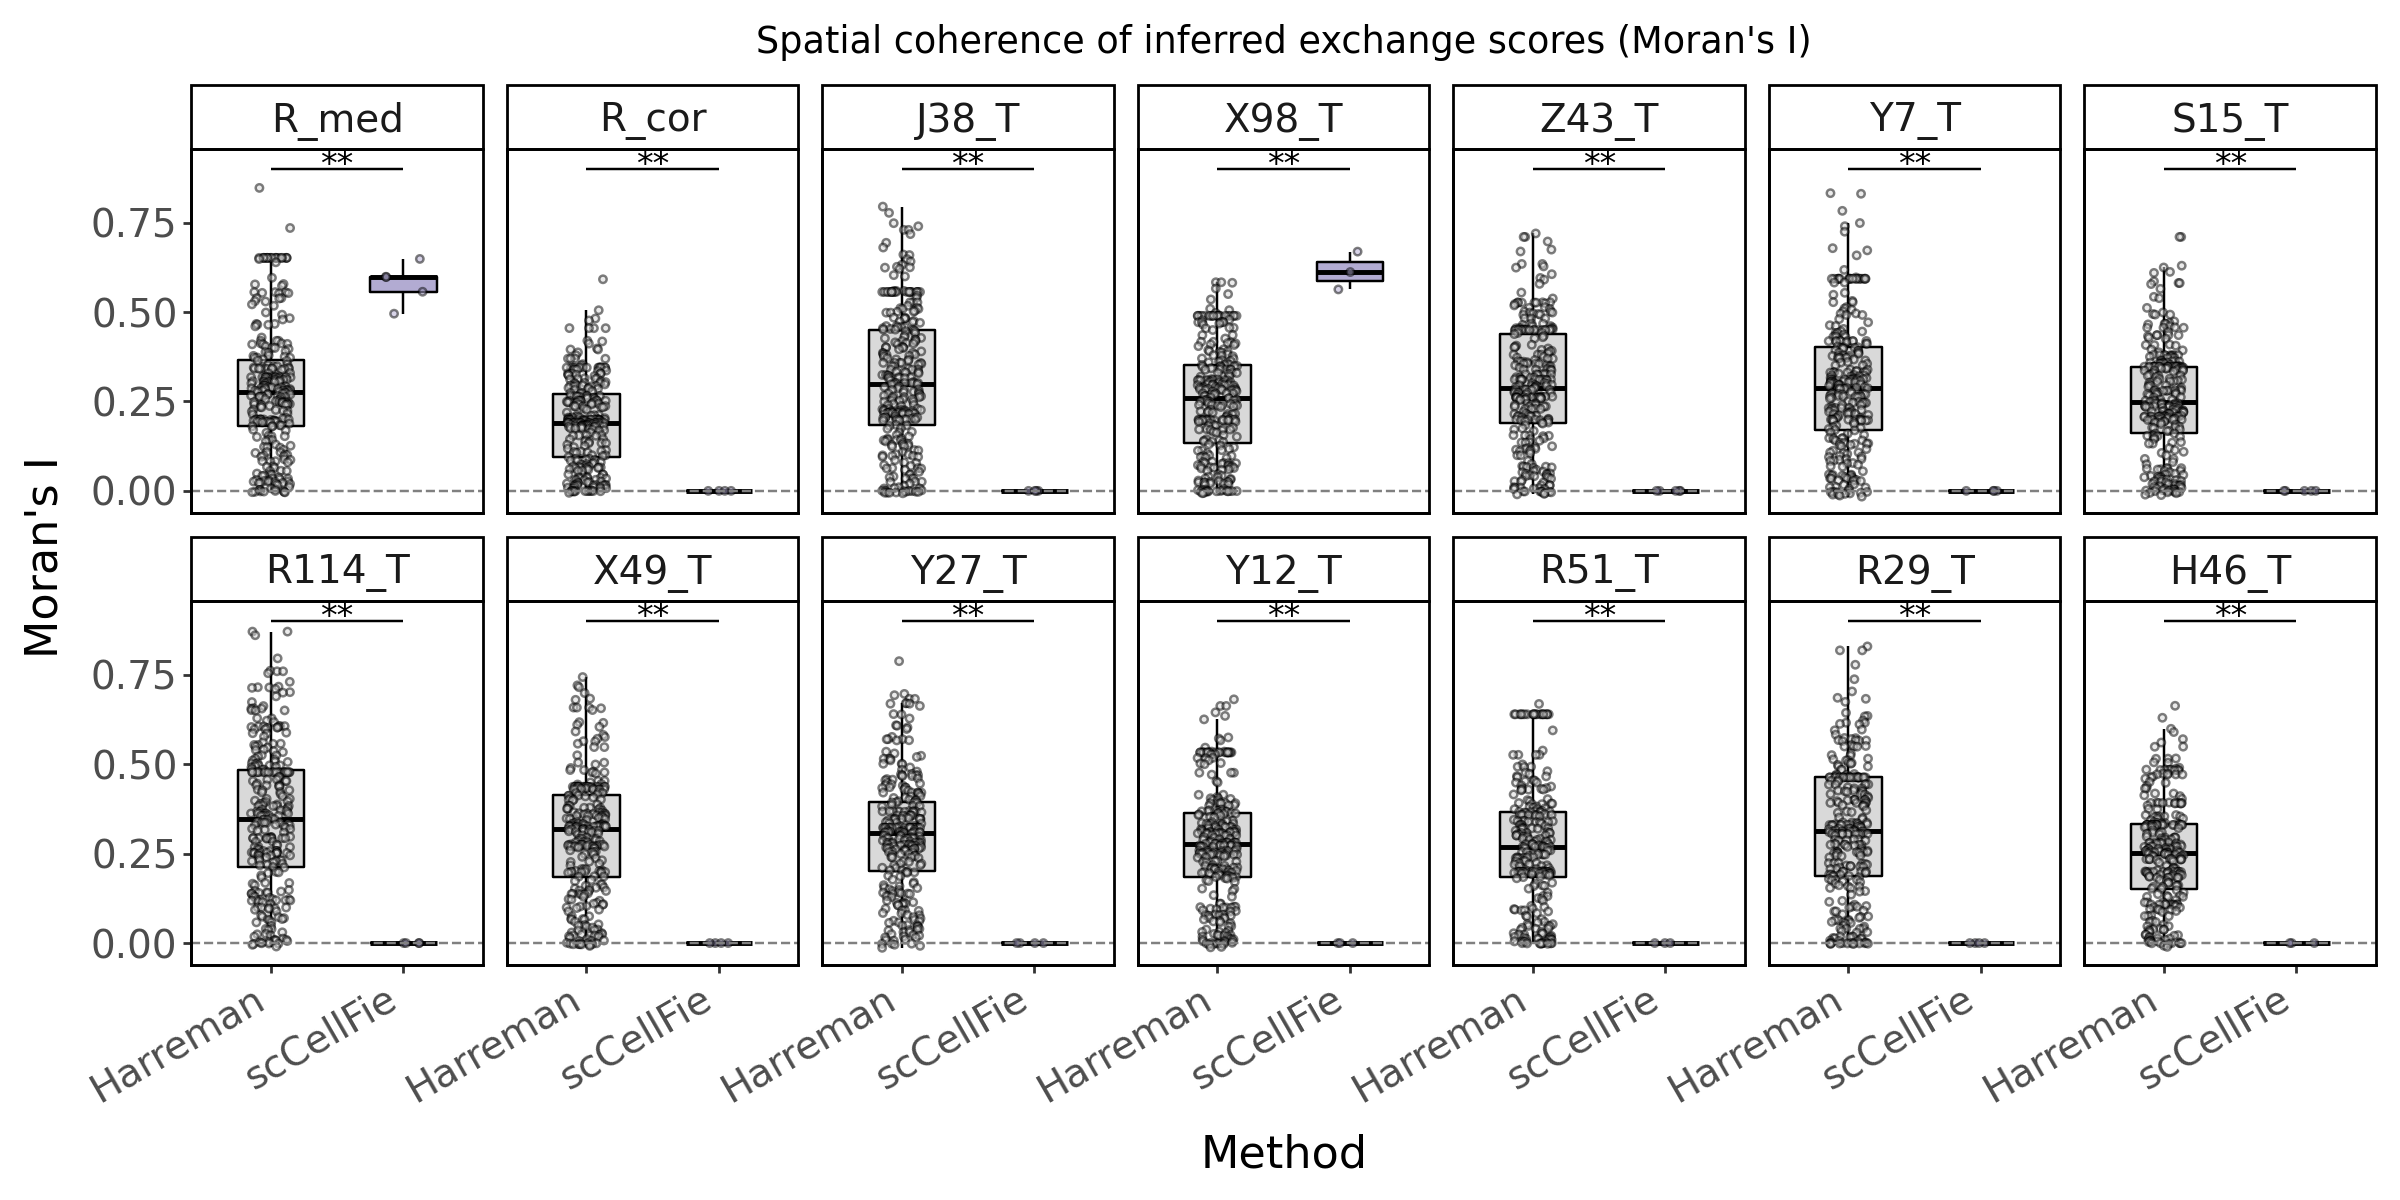

Figure saved to /home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC/plots/morans_i_per_sample.svg


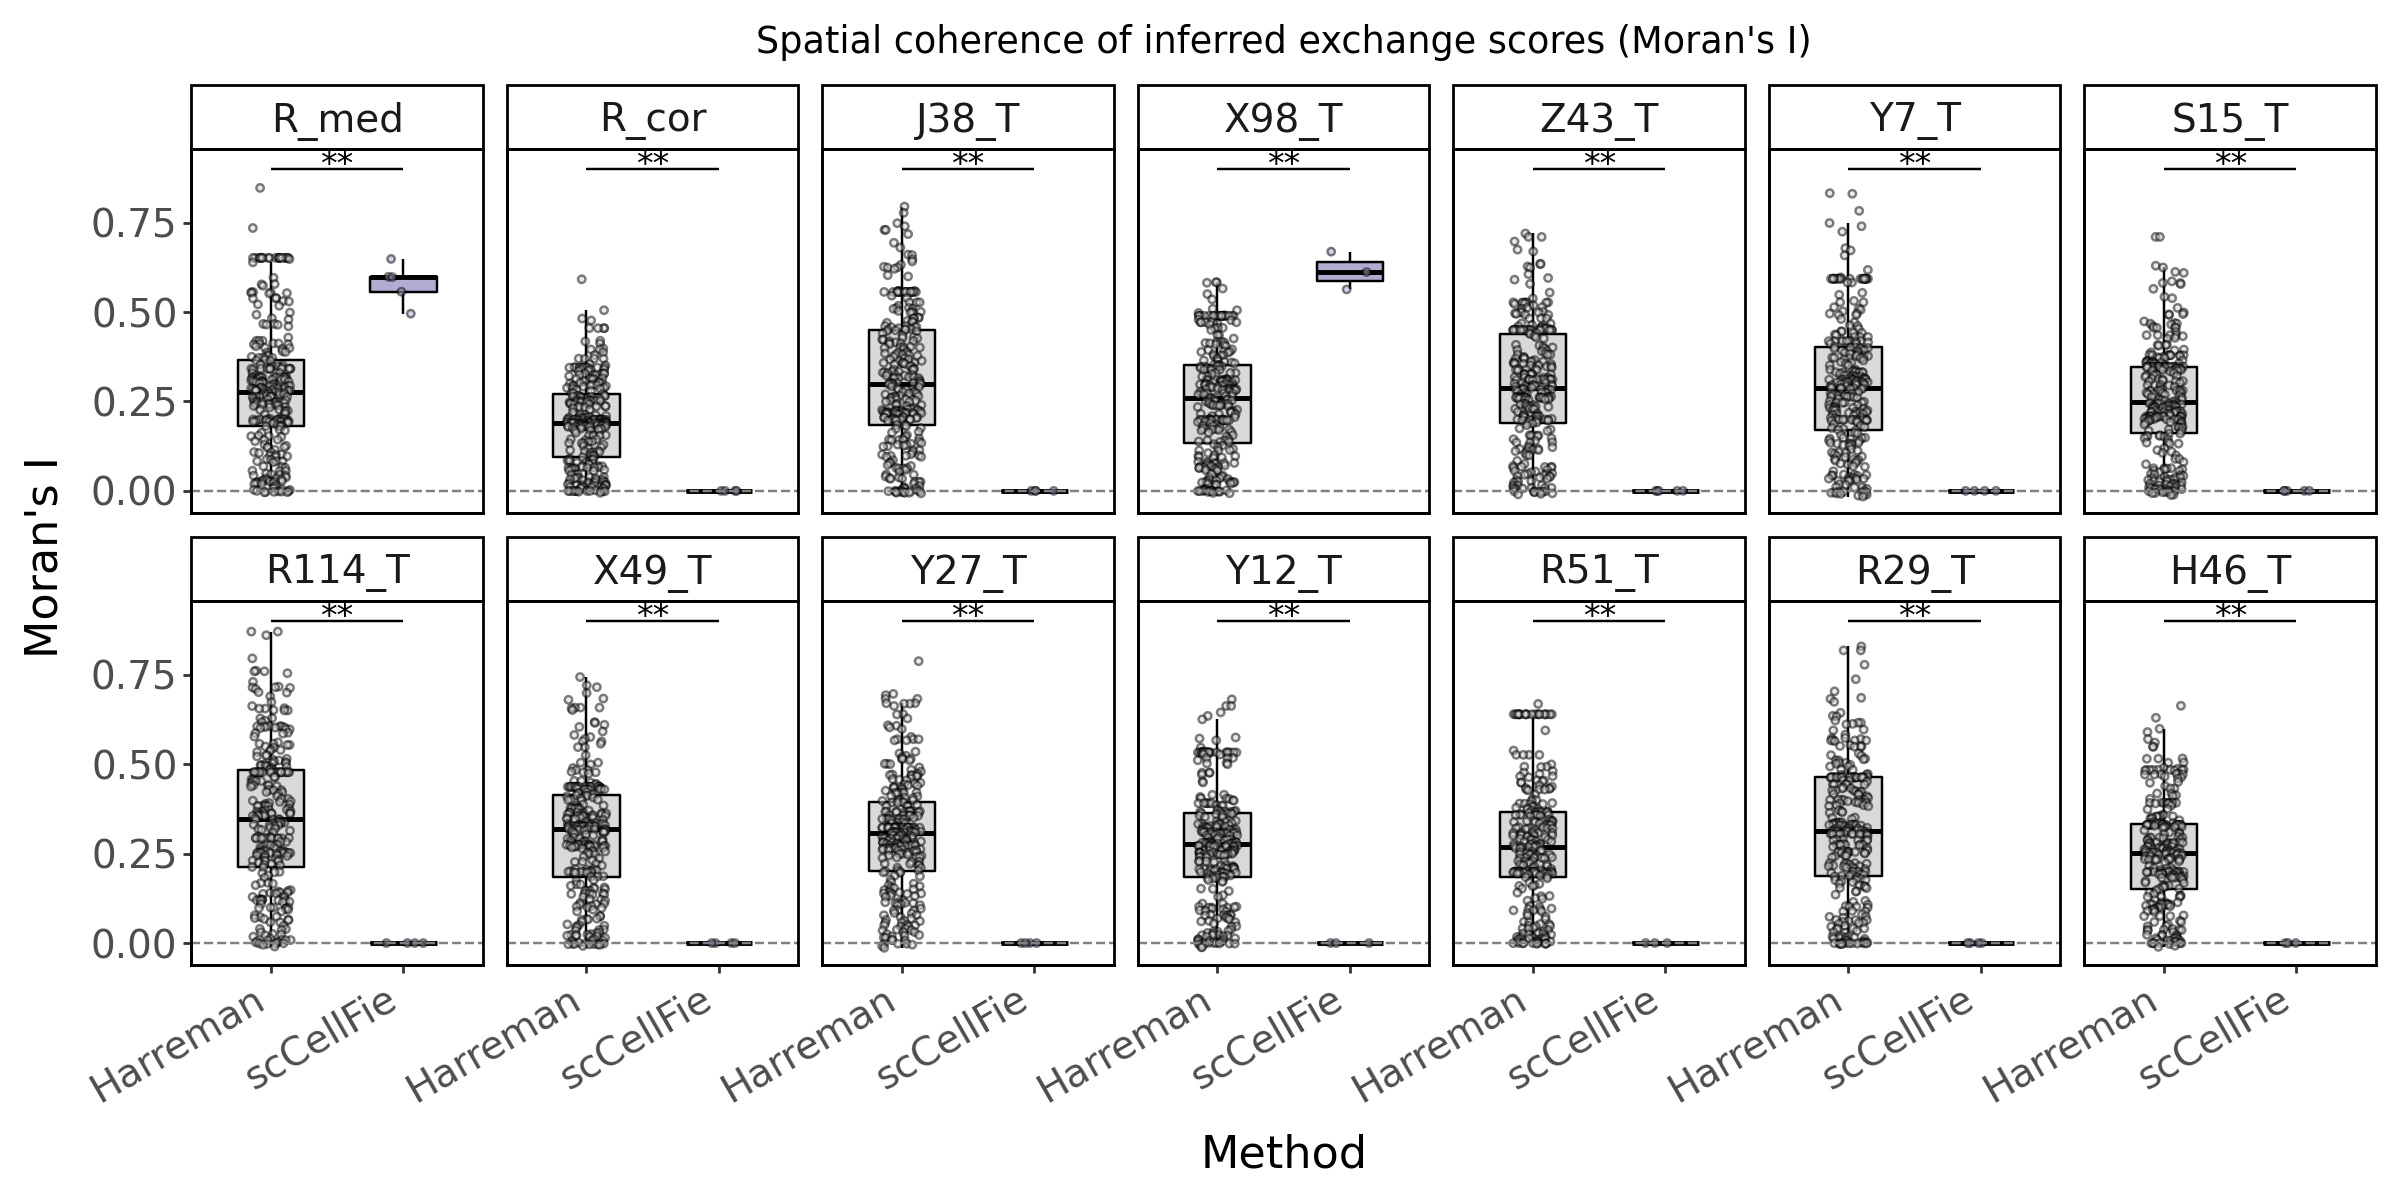

In [10]:
# Per-sample violin plot
plot_morans_i(
    results_df, mwu_df,
    sample_order=SAMPLE_ORDER,
    save_path=f"{PLOTS_PATH}/morans_i_per_sample.svg",
)


Global Mann-Whitney U (all samples pooled):
  Harreman median I = 0.2776
  scCellFie median I = 0.0000
  U = 187498.0, p = 1.9033e-17


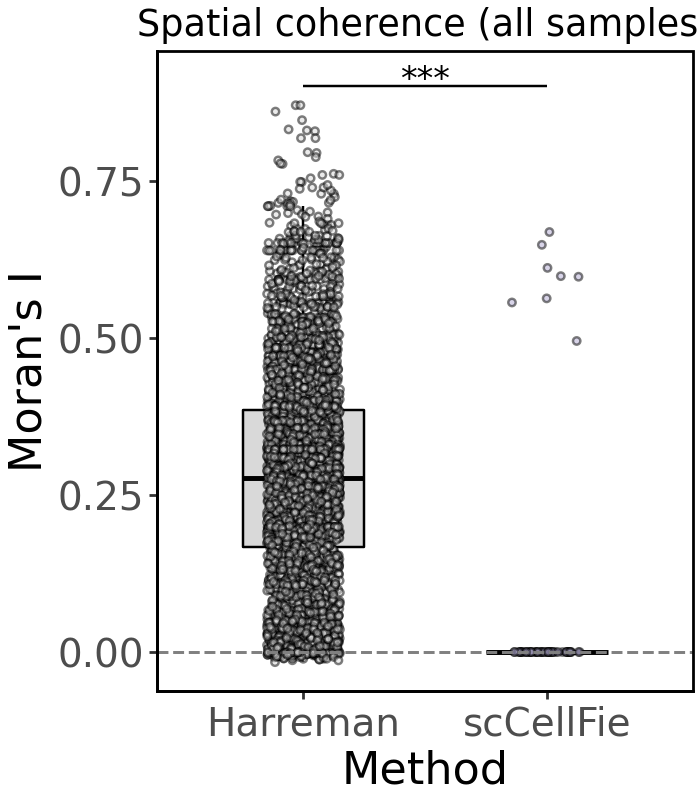

Figure saved to /home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC/plots/morans_i_global.svg


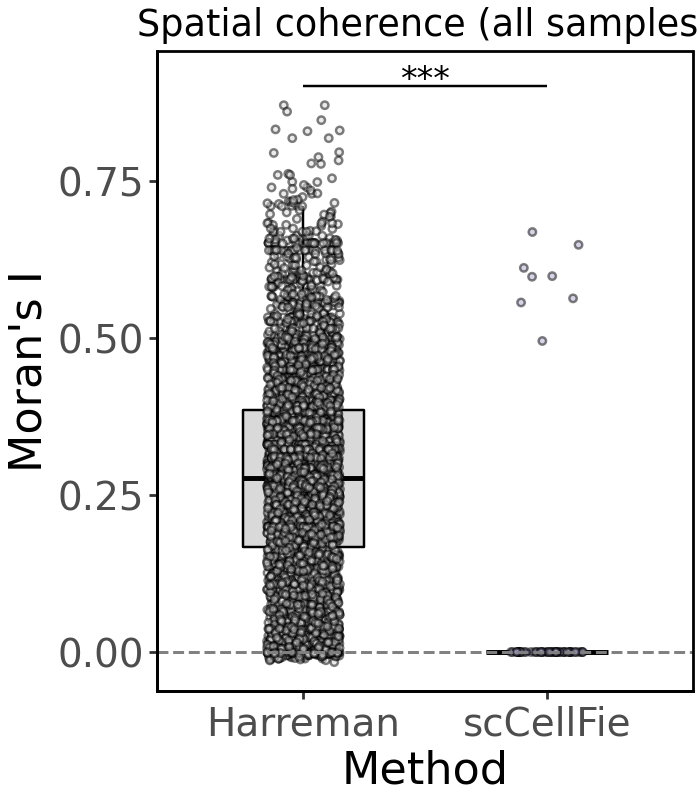

In [11]:
# Global summary plot
plot_morans_i_global(
    results_df, mwu_df,
    save_path=f"{PLOTS_PATH}/morans_i_global.svg",
)